In [2]:
import csv
import os
from typing import Literal
from dataclasses import dataclass
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize

PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

In [3]:
random.seed(42)
np.random.seed(42)

In [4]:
DATADIR_PATH = "./Data"

@dataclass
class SubjectResult:
    filename: str
    gender: str
    trial: int
    choice: int
    outcome: str
    choice_rt: float
    confidence_level: int
    confidence_rt: float
    next_trial_rt: float
    card_probs: list[float]


def read_subject_data(gender: Literal['Male', 'Female'], filename: str) -> list[SubjectResult]:
    filepath = os.path.join(DATADIR_PATH, gender, filename)
    results: list[SubjectResult] = []
    with open(filepath, newline='') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            results.append(SubjectResult(
                filename=filename,
                gender=gender,
                trial=int(row['trial']),
                choice=int(row['choice']),
                outcome=row['outcome'],
                choice_rt=float(row['choice_rt']),
                confidence_level=int(row['confidence_level']),
                confidence_rt=float(row['confidence_rt']),
                next_trial_rt=float(row['next_trial_rt']),
                card_probs=eval(row['card probs']),
            ))
    return results


def read_all_data() -> list[SubjectResult]:
    all_results: list[SubjectResult] = []
    for gender in ('Male', 'Female'):
        gender_dir = os.path.join(DATADIR_PATH, gender)
        for filename in os.listdir(gender_dir):
            all_results.extend(read_subject_data(gender, filename))
    return all_results


subjects_data = read_all_data()
df = pd.DataFrame([vars(r) for r in subjects_data])

def assign_block(trial):
    if trial < 15:
        return 1
    elif trial < 45:
        return 2
    return 3

df['block'] = df['trial'].apply(assign_block)
df['trial_in_block'] = df.groupby(['filename', 'block']).cumcount() + 1
df['chosen_probability'] = df.apply(lambda row: row['card_probs'][row['choice']], axis=1)
df['optimal_choice'] = (df['chosen_probability'] == df['card_probs'].apply(max)).astype(int)
df['rewarded'] = (df['outcome'] == 'win').astype(int)

df.head()

,filename,gender,trial,choice,outcome,choice_rt,confidence_level,confidence_rt,next_trial_rt,card_probs,block,trial_in_block,chosen_probability,optimal_choice,rewarded
0,subject3.csv,Male,0,1,win,2.865571,3,3.362912,1.389576,"[0.6, 0.7, 0.4, 0.5]",1,1,0.7,1,1
1,subject3.csv,Male,1,3,lose,3.235349,2,2.570418,0.749804,"[0.6, 0.7, 0.4, 0.5]",1,2,0.5,0,0
2,subject3.csv,Male,2,0,win,4.040312,2,1.957961,0.466987,"[0.6, 0.7, 0.4, 0.5]",1,3,0.6,0,1
3,subject3.csv,Male,3,1,win,3.209114,2,1.417447,0.726657,"[0.6, 0.7, 0.4, 0.5]",1,4,0.7,1,1
4,subject3.csv,Male,4,0,lose,4.824815,2,1.825226,0.987631,"[0.6, 0.7, 0.4, 0.5]",1,5,0.6,0,0


In [5]:
# df = df[(df["filename"] == 'subject3.csv') | (df["filename"] == "subject2.csv")]
# df


In [6]:
df["filename-block"] = df.apply(lambda row: f"{row['filename']}-block{row['block']}", axis=1)
def simulate_subject(params, choices, outcomes, policy='softmax', seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    alpha, beta, epsilon = params
    n_actions = 4
    Q = np.zeros(n_actions)
    td_errors = []
    mismatches = []
    log_lik = 0.0
    eps = 1e-7
    action_counts = np.zeros(n_actions) + eps
    
    for a, r in zip(choices, outcomes):
        if policy == 'softmax':
            p = np.exp(beta * Q) / np.sum(np.exp(beta * Q))
        elif policy == 'egreedy':
            if np.random.rand() < epsilon:
                p = np.ones(n_actions) / n_actions
            else:
                p = np.zeros(n_actions)
                p[np.argmax(Q)] = 1.0
        elif policy == 'ucb':
            scores = Q + beta * np.sqrt(np.log(action_counts.sum() + 1) / action_counts) 
            p = np.zeros(n_actions)
            p[np.argmax(scores)] = 1.0
        else:
            raise ValueError(f'Unknown policy: {policy}')
        
        predicted = int(np.argmax(p))
        mismatches.append(1 if predicted != a else 0)
        log_lik += np.log(p[a] + 1e-10)
        td_errors.append(r - Q[a])
        Q[a] = Q[a] + alpha * (r - Q[a])
        action_counts[a] += 1
    
    n_mismatches = sum(mismatches)
    return -log_lik, td_errors, n_mismatches, mismatches


def fit_subject(choices, outcomes, policy='softmax'):
    np.random.seed(42)
    
    def neg_log_lik(params):
        ll, _, _, _ = simulate_subject(params, choices, outcomes, policy)
        return ll
    
    best_nll = np.inf
    best_params = None
    
    for _ in range(20):
        x0 = np.array([
            np.random.uniform(0.01, 0.5),
            np.random.uniform(1.0, 20.0),
            np.random.uniform(0.01, 0.5)
        ])
        bounds = [(0.001, 0.99), (0.1, 50.0), (0.001, 0.99)]
        
        try:
            res = minimize(neg_log_lik, x0, bounds=bounds, method='L-BFGS-B')
            if res.fun < best_nll and res.success:
                best_nll = res.fun
                best_params = res.x
        except Exception:
            continue
    
    if best_params is None:
        return None
    
    nll, td_errors, n_mismatches, mismatches = simulate_subject(best_params, choices, outcomes, policy)
    aic = 2 * len(best_params) + 2 * best_nll
    bic = np.log(len(choices)) * len(best_params) + 2 * best_nll
    
    return {
        'params': best_params,
        'nll': best_nll,
        'aic': aic,
        'bic': bic,
        'td_errors': td_errors,
        'n_mismatches': n_mismatches,
        'mismatches': mismatches
    }


def fit_all_subjects(df, policy='softmax'):
    results = []
    for subj, group in tqdm(df.groupby('filename-block')):
        choices = group['choice'].values
        outcomes = (group['outcome'] == 'win').astype(int).values
        fit = fit_subject(choices, outcomes, policy)
        if fit is not None:
            fit['filename'] = subj
            fit['policy'] = policy
            results.append(fit)
    return pd.DataFrame(results)


In [7]:

print('Fitting Softmax model...')
softmax_df = fit_all_subjects(df, policy='softmax')

print('Fitting Epsilon-greedy model...')
egreedy_df = fit_all_subjects(df, policy='egreedy')

print('Fitting ucb model...')
ucb_df = fit_all_subjects(df, policy='ucb')

all_models = pd.concat([softmax_df, egreedy_df, ucb_df], ignore_index=True)

print(f'\nFitted {len(all_models)} subject-model combinations')
print(f'Softmax: {len(softmax_df)} subjects')
print(f'Epsilon-greedy: {len(egreedy_df)} subjects')
print(f'ucb: {len(ucb_df)} subjects')

all_models.head()

Fitting Softmax model...


100%|██████████| 120/120 [00:27<00:00,  4.35it/s]


Fitting Epsilon-greedy model...


100%|██████████| 120/120 [00:28<00:00,  4.25it/s]


Fitting ucb model...


100%|██████████| 120/120 [00:02<00:00, 57.71it/s]


Fitted 360 subject-model combinations
Softmax: 120 subjects
Epsilon-greedy: 120 subjects
ucb: 120 subjects


,params,nll,aic,bic,td_errors,n_mismatches,mismatches,filename,policy
0,"[0.011356259116921978, 50.0, 0.30980791841396593]",18.449867,42.899735,45.023885,"[1.0, 1.0, 0.0, 0.0, -0.011356259116921978, 0....",7,"[0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0]",subject1.csv-block1,softmax
1,"[0.3902732521015163, 6.441325764968593, 0.0327...",14.917902,35.835804,40.039396,"[0.0, 0.0, 0.0, 1.0, 0.6097267478984837, -0.62...",5,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",subject1.csv-block2,softmax
2,"[0.29458471377187756, 7.957601767191907, 0.053...",27.501206,61.002411,67.285445,"[0.0, 0.0, 1.0, 0.7054152862281224, 0.49761072...",11,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",subject1.csv-block3,softmax
3,"[0.0050511843621346905, 50.0, 0.2526366859545224]",20.095188,46.190377,48.314527,"[0.0, 0.0, 1.0, 1.0, 0.9949488156378653, 0.989...",7,"[0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0]",subject10.csv-block1,softmax
4,"[0.1827259174481675, 6.13161237435067, 0.44846...",34.866877,75.733755,79.937347,"[1.0, -0.1827259174481675, 1.0, -0.18272591744...",12,"[1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, ...",subject10.csv-block2,softmax


In [8]:
comparison = all_models.groupby('policy').agg({
    'nll': ['mean', 'std'],
    'aic': ['mean', 'std'],
    'bic': ['mean', 'std']
}).round(4)

comparison

nll                  aic                  bic          
             mean       std       mean       std       mean       std
policy                                                               
egreedy  226.9245  162.6901   459.8490  325.3802   464.0526  326.5398
softmax   34.5608   23.1784    75.1217   46.3569    79.3253   47.6191
ucb      592.1481  362.7243  1190.2963  725.4486  1194.4999  726.9986

In [9]:
mismatch_summary = all_models.groupby('policy')['n_mismatches'].agg(['mean', 'std', 'min', 'max']).round(2)
mismatch_summary.columns = ['Mean', 'Std', 'Min', 'Max']
mismatch_summary


,Mean,Std,Min,Max
policy,,,,
egreedy,20.48,12.07,0,49
softmax,16.99,11.96,0,49
ucb,25.72,15.75,2,58


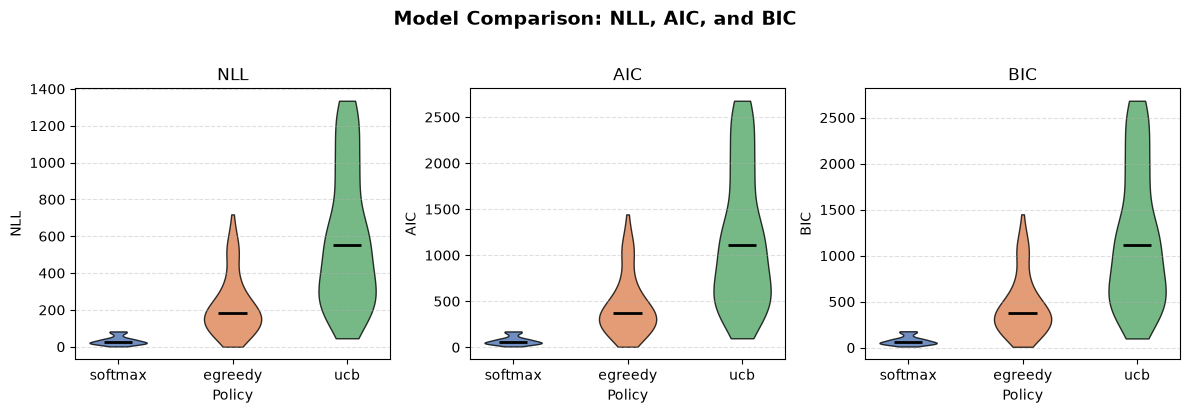

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

policies = ["softmax", "egreedy", "ucb"]

for ax, metric in zip(axes, ["nll", "aic", "bic"]):
    data = [
        all_models.loc[all_models["policy"] == policy, metric].values
        for policy in policies
    ]

    vp = ax.violinplot(
        data,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Color each violin
    for body, color in zip(vp["bodies"], PALETTE[:3]):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.8)

    # Style median line
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(2)

    ax.set_xticks(range(1, len(policies) + 1))
    ax.set_xticklabels(policies)
    ax.set_ylabel(metric.upper())
    ax.set_xlabel("Policy")
    ax.set_title(metric.upper())
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(
    "Model Comparison: NLL, AIC, and BIC",
    y=1.02,
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("report/pics/model_comparison_nll_aic_bic.png", dpi=150)
plt.show()

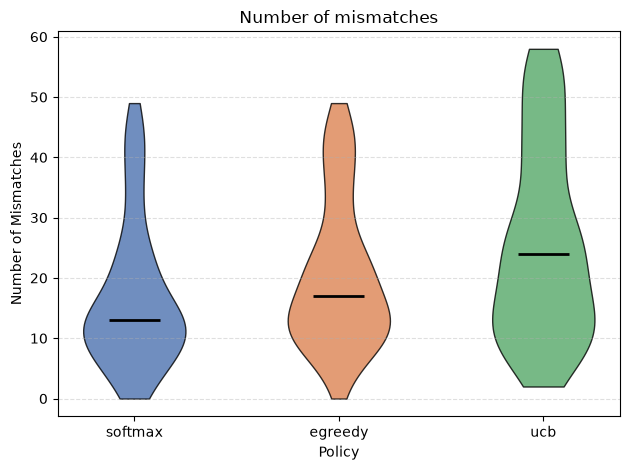

In [11]:

policies = ["softmax", "egreedy", "ucb"]

data = [
    all_models.loc[all_models["policy"] == policy,"n_mismatches"].values
    for policy in policies
]

vp = plt.violinplot(
    data,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

# Color each violin
for body, color in zip(vp["bodies"], PALETTE[:3]):
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.8)

# Style median line
vp["cmedians"].set_color("black")
vp["cmedians"].set_linewidth(2)

plt.xticks(range(1, len(policies) + 1), policies)
plt.ylabel("Number of Mismatches")
plt.xlabel("Policy")
plt.title("Number of mismatches")
plt.grid(axis="y", linestyle="--", alpha=0.4)


plt.tight_layout()
plt.savefig("report/pics/number_of_mismatches.png", dpi=150)
plt.show()

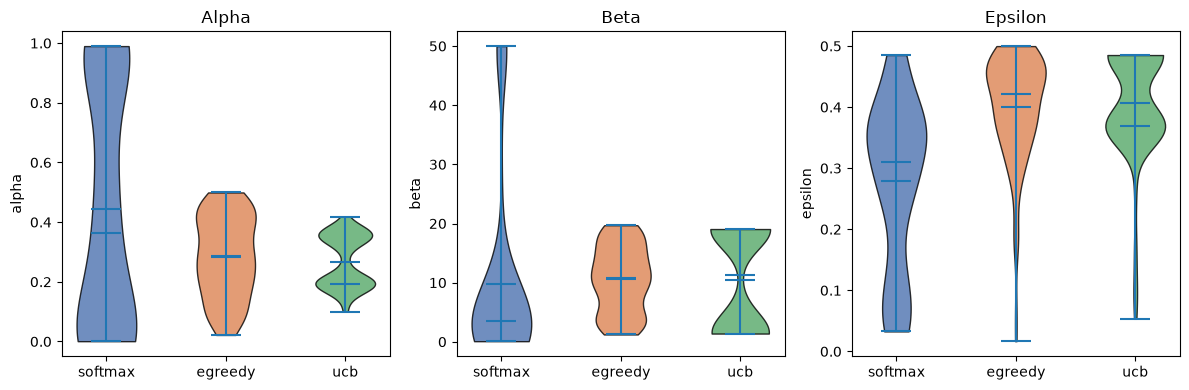

In [12]:
policies = ("softmax", "egreedy", "ucb")
parameters = ("alpha", "beta", "epsilon")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for j, parameter in enumerate(parameters):
    violin_data = []

    for policy in policies:
        model_params = all_models.loc[
            all_models["policy"] == policy, "params"
        ].to_numpy()
        model_params = np.vstack(model_params)

        violin_data.append(model_params[:, j])

    vp = axes[j].violinplot(
        violin_data,
        showmeans=True,
        showmedians=True
    )

    for body, color in zip(vp["bodies"], PALETTE[:3]):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.8)

    axes[j].set_xticks([1, 2, 3])
    axes[j].set_xticklabels(policies)
    axes[j].set_title(parameter.capitalize())
    axes[j].set_ylabel(parameter)

plt.tight_layout()
plt.savefig("report/pics/parameter_violin_plots.png", dpi=150)
plt.show()

In [13]:
all_models

,params,nll,aic,bic,td_errors,n_mismatches,mismatches,filename,policy
0,"[0.011356259116921978, 50.0, 0.30980791841396593]",18.449867,42.899735,45.023885,"[1.0, 1.0, 0.0, 0.0, -0.011356259116921978, 0....",7,"[0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0]",subject1.csv-block1,softmax
1,"[0.3902732521015163, 6.441325764968593, 0.0327...",14.917902,35.835804,40.039396,"[0.0, 0.0, 0.0, 1.0, 0.6097267478984837, -0.62...",5,"[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",subject1.csv-block2,softmax
2,"[0.29458471377187756, 7.957601767191907, 0.053...",27.501206,61.002411,67.285445,"[0.0, 0.0, 1.0, 0.7054152862281224, 0.49761072...",11,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",subject1.csv-block3,softmax
3,"[0.0050511843621346905, 50.0, 0.2526366859545224]",20.095188,46.190377,48.314527,"[0.0, 0.0, 1.0, 1.0, 0.9949488156378653, 0.989...",7,"[0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0]",subject10.csv-block1,softmax
4,"[0.1827259174481675, 6.13161237435067, 0.44846...",34.866877,75.733755,79.937347,"[1.0, -0.1827259174481675, 1.0, -0.18272591744...",12,"[1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, ...",subject10.csv-block2,softmax
...,...,...,...,...,...,...,...,...,...
355,"[0.35695556312006227, 1.3911053916202465, 0.48...",460.517019,927.034037,931.237629,"[0.0, 0.0, 1.0, 0.6430444368799377, 0.41350614...",20,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, ...",subject8.csv-block2,ucb
356,"[0.35695556312006227, 1.3911053916202465, 0.48...",944.059888,1894.119776,1900.402810,"[0.0, 0.0, 1.0, 0.6430444368799377, 0.41350614...",41,"[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, ...",subject8.csv-block3,ucb
357,"[0.19352465823520762, 19.063571821788408, 0.36...",207.232658,420.465317,422.589467,"[1.0, 1.0, 0.8064753417647924, 1.0, 1.0, 0.806...",9,"[1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1]",subject9.csv-block1,ucb
358,"[0.19352465823520762, 19.063571821788408, 0.36...",460.517019,927.034037,931.237629,"[0.0, 1.0, 0.0, 1.0, -0.19352465823520762, 1.0...",20,"[1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, ...",subject9.csv-block2,ucb
